In [1]:
""""
Data analyses on Change requests of 3GPP
Made by: Bram Bouman
Date: 28/05/2026
"""

import pandas as pd

########################
#### load the data: ####
########################

CR_rel20 = pd.read_csv("CRdata/CR-rel20-data.csv")
CR_rel19 = pd.read_csv("CRdata/CR-rel19-data.csv")
CR_rel18 = pd.read_csv("CRdata/CR-rel18-data.csv")
CR_rel17 = pd.read_csv("CRdata/CR-rel17-data.csv")
CR_rel16 = pd.read_csv("CRdata/CR-rel16-data.csv")
CR_rel15 = pd.read_csv("CRdata/CR-rel15-data.csv")

CR_rel20 = CR_rel20[CR_rel20["tdoctype"] == "CR"]
CR_rel19 = CR_rel19[CR_rel19["tdoctype"] == "CR"]
CR_rel18 = CR_rel18[CR_rel18["tdoctype"] == "CR"]
CR_rel17 = CR_rel17[CR_rel17["tdoctype"] == "CR"]
CR_rel16 = CR_rel16[CR_rel16["tdoctype"] == "CR"]
CR_rel15 = CR_rel15[CR_rel15["tdoctype"] == "CR"]

C:\Users\Bram\AppData\Local\Temp\ipykernel_67044\3234810484.py:14: DtypeWarning: Columns (0: crspec) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_rel19 = pd.read_csv("CRdata/CR-rel19-data.csv")
C:\Users\Bram\AppData\Local\Temp\ipykernel_67044\3234810484.py:16: DtypeWarning: Columns (0: crnumber, 1: uicc_affected, 2: me_affected, 3: ran_affected, 4: cn_affected, 5: clauses_affected) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_rel17 = pd.read_csv("CRdata/CR-rel17-data.csv")
C:\Users\Bram\AppData\Local\Temp\ipykernel_67044\3234810484.py:17: DtypeWarning: Columns (0: crspec, 1: uicc_affected, 2: me_affected, 3: ran_affected, 4: cn_affected, 5: clauses_affected) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_rel16 = pd.read_csv("CRdata/CR-rel16-data.csv")
C:\Users\Bram\AppData\Local\Temp\ipykernel_67044\3234810484.py:18: DtypeWarning: Columns (0: crspec, 1: uicc_affected, 2: me_affected, 3: 

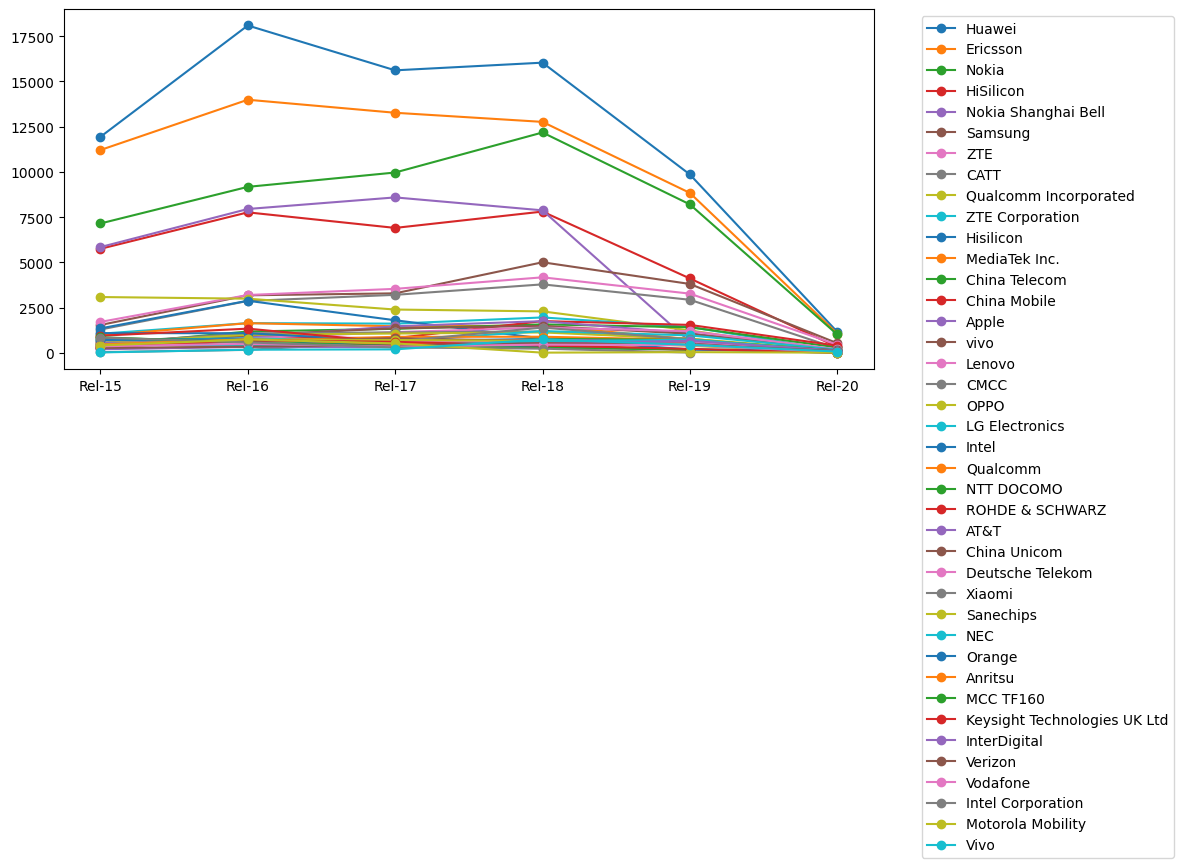

In [ ]:
def CR_sources(CR_rel):
    CR_rel["source"] = CR_rel["source"].fillna("")
    comp_rel = [part for item in CR_rel["source"] for part in item.split(',')]
    comp_rel = [s.split('/')[0].strip() for s in comp_rel]

    comp_rel = pd.DataFrame({
        "company": pd.Series(comp_rel).value_counts().index,
        f"{CR_rel['release'].iloc[0]}": pd.Series(comp_rel).value_counts().values
    })
    return comp_rel

comp_rel15 = CR_sources(CR_rel15)
comp_rel16 = CR_sources(CR_rel16)
comp_rel17 = CR_sources(CR_rel17)
comp_rel18 = CR_sources(CR_rel18)
comp_rel19 = CR_sources(CR_rel19)
comp_rel20 = CR_sources(CR_rel20)

dfs = [
    comp_rel15,
    comp_rel16,
    comp_rel17,
    comp_rel18,
    comp_rel19,
    comp_rel20
]

comp_total = dfs.reduce(
    lambda left, right: pd.merge(left, right, on="company", how="outer"),
    dfs
)

def top_contributers(number):
    """"
    get top contributers in change requests, 
    input: amount of top contributers you want to see
    output: plot with top contributers over the releases: 15 until 20
    """

    comp_total['total'] = comp_total[['Rel-15','Rel-16','Rel-17','Rel-18','Rel-19','Rel-20']].sum(axis=1)
    top20_total = comp_total.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top20_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T

    plt.figure(figsize=(12, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return 

top_contributers(40)

C:\Users\Bram\AppData\Local\Temp\ipykernel_67044\426314423.py:2: DtypeWarning: Columns (0: Spec number, 1: CR number) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_ftpserver = pd.read_csv("CRdata/CRDB_20260120.csv")


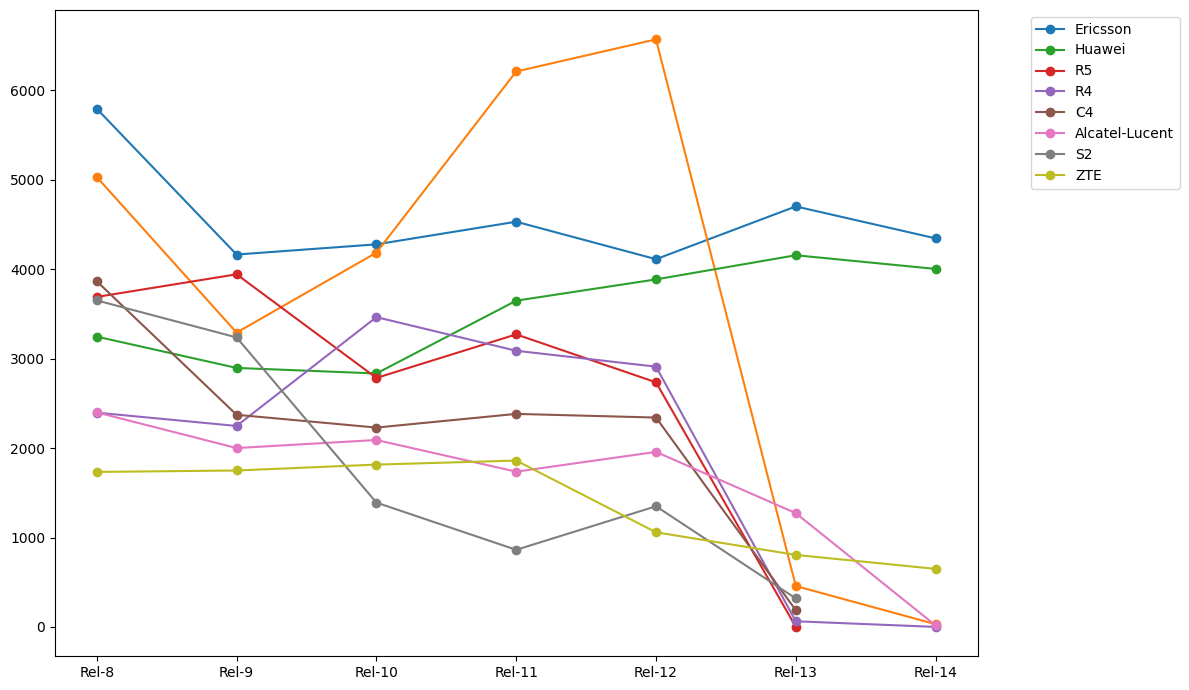

In [15]:

import pandas as pd
CR_ftpserver = pd.read_csv("CRdata/CRDB_20260120.csv")

def get_release(df,number):
    data_release = df[df["Release"].str.contains(f"Rel-{number}", na=False)]
    return data_release


## get the release
CRft_rel8 = get_release(CR_ftpserver,8)
CRft_rel9 = get_release(CR_ftpserver,9)
CRft_rel10 = get_release(CR_ftpserver,10)
CRft_rel11 = get_release(CR_ftpserver,11)
CRft_rel12 = get_release(CR_ftpserver,12)
CRft_rel13 = get_release(CR_ftpserver,13)
CRft_rel14 = get_release(CR_ftpserver,14)

## put sources of WG and TSG together, because in DB its one of the two 
CRft_rel8["source"] = CRft_rel8["WGSourceOrganizations"] + "," + CRft_rel8["TSGSourceOrganizations"]
CRft_rel9["source"] = CRft_rel9["WGSourceOrganizations"] + "," + CRft_rel9["TSGSourceOrganizations"]
CRft_rel10["source"] = CRft_rel10["WGSourceOrganizations"] + "," + CRft_rel10["TSGSourceOrganizations"]
CRft_rel11["source"] = CRft_rel11["WGSourceOrganizations"] + "," + CRft_rel11["TSGSourceOrganizations"]
CRft_rel12["source"] = CRft_rel12["WGSourceOrganizations"] + "," + CRft_rel12["TSGSourceOrganizations"]
CRft_rel13["source"] = CRft_rel13["WGSourceOrganizations"] + "," + CRft_rel13["TSGSourceOrganizations"]
CRft_rel14["source"] = CRft_rel14["WGSourceOrganizations"] + "," + CRft_rel14["TSGSourceOrganizations"]

## rename the Release to release
CRft_rel8 = CRft_rel8.rename(columns = {"Release" : "release"})
CRft_rel9 = CRft_rel9.rename(columns = {"Release" : "release"})
CRft_rel10 = CRft_rel10.rename(columns = {"Release" : "release"})
CRft_rel11 = CRft_rel11.rename(columns = {"Release" : "release"})
CRft_rel12 = CRft_rel12.rename(columns = {"Release" : "release"})
CRft_rel13 = CRft_rel13.rename(columns = {"Release" : "release"})
CRft_rel14 = CRft_rel14.rename(columns = {"Release" : "release"})

## use definition from earlier to extract info

from functools import reduce

compft_rel8 = CR_sources(CRft_rel8)
compft_rel9 = CR_sources(CRft_rel9)
compft_rel10 = CR_sources(CRft_rel10)
compft_rel11 = CR_sources(CRft_rel11)
compft_rel12 = CR_sources(CRft_rel12)
compft_rel13 = CR_sources(CRft_rel13)
compft_rel14 = CR_sources(CRft_rel14)


dfs = [
    compft_rel8,
    compft_rel9,
    compft_rel10,
    compft_rel11,
    compft_rel12,
    compft_rel13,
    compft_rel14
]

compft_total = reduce(
    lambda left, right: pd.merge(left, right, on="company", how="outer"),
    dfs
)

def top_contributers(number):
    """"
    get top contributers in change requests, 
    input: amount of top contributers you want to see
    output: plot with top contributers over the releases: 15 until 20
    """

    compft_total['total'] = compft_total[['Rel-8','Rel-9','Rel-10','Rel-11','Rel-12','Rel-13','Rel-14']].sum(axis=1)
    top20_total = compft_total.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top20_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T
    df_plot = df_plot.drop(columns = "-")

    plt.figure(figsize=(12, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return 

top_contributers(10)

C:\Users\Bram\AppData\Local\Temp\ipykernel_22264\1552556959.py:4: DtypeWarning: Columns (0: abstract, 1: secretary_remarks, 2: ainumber, 3: ainame, 4: revisionof, 5: revisedto, 6: release, 7: crspec, 8: crspecversion, 9: workitem, 10: crnumber, 11: uicc_affected, 12: me_affected, 13: ran_affected, 14: cn_affected, 15: clauses_affected, 16: crsinpack) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('CRdata/total_DB_CR.csv')


853984.0


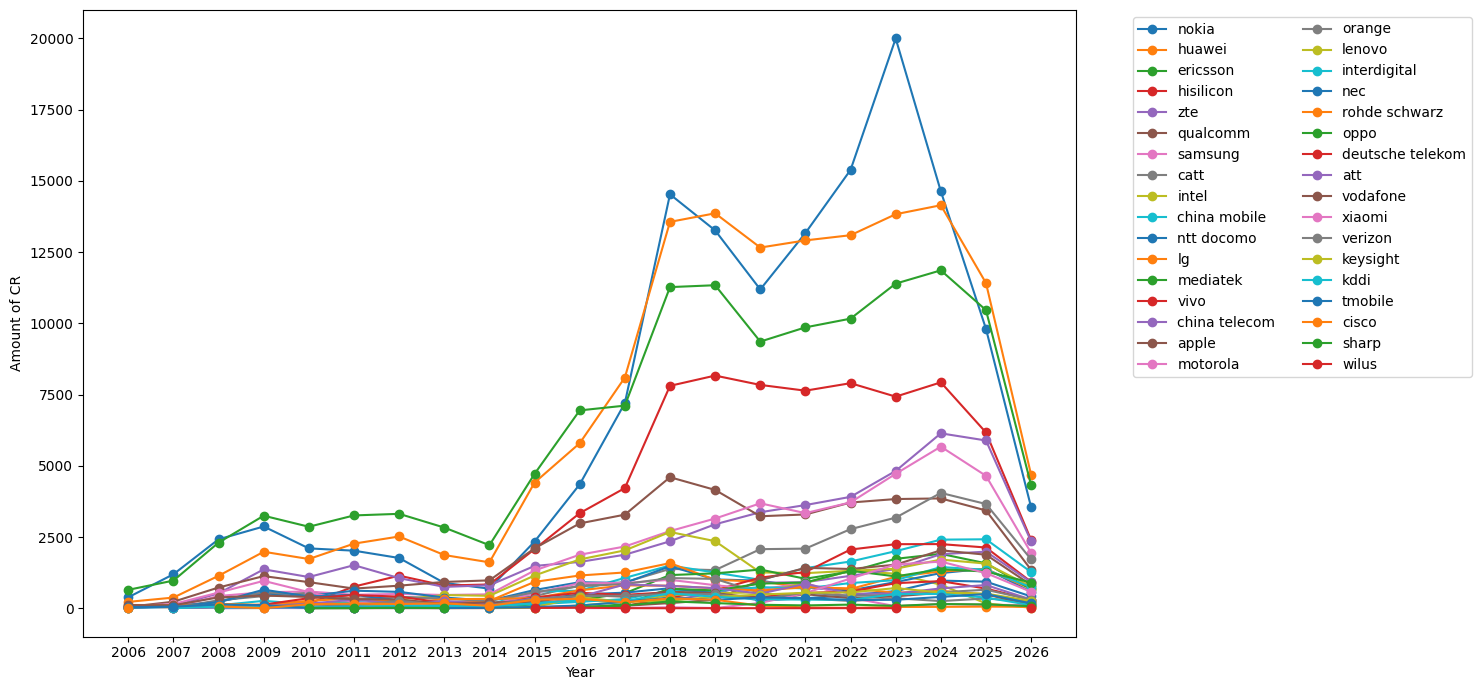

In [36]:
import pandas as pd 
import regex as re

df = pd.read_csv('CRdata/total_DB_CR.csv')

def splitcompanies(df):
    """"
    split the different companies associcated with the CR 
    """
    df["source"] = df["source"].fillna("")
    df["source"] = df["source"].str.split(r"[,/]")
    df = df.explode("source")
    return df
df = splitcompanies(df)

def normalize_name(name):
    import regex as re

    # lowercase
    name = name.lower()

    name = re.sub(r'\b(inc|incorporated|ltd|llc|corp|corporation|lm)\b', '', name)

    # remove text inside parentheses
    name = re.sub(r'\(.*?\)', '', name)

    # remove punctuation, dashes, question marks, etc.
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # remove extra whitespace
    name = ' '.join(name.split())
    return name

df["source"] = df["source"].apply(normalize_name)
df["source"] = df["source"].str.strip()
df2 = df
companies = [
    "huawei", "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "mediatek", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att",
    "kddi", "cisco", "sharp", "wilus"
]

patterns = {
    company: re.compile(r'\b' + re.escape(company) + r'\b', re.IGNORECASE)
    for company in companies
}

def find_company(name):
    name = str(name)

    for company, pattern in patterns.items():
        if pattern.search(name):
            return company
df['source'] = df['source'].apply(find_company)

processed_CR = df
def countcompanies(df,startyear,endyear):
    """"
    get the amount of times each company made a change request for each year
    """
    temp = df[df["year"] == startyear]
    counts = temp["source"].value_counts()
    companies = pd.DataFrame({
        "company": counts.index,
        f"{startyear}": counts.values
    })

    for i in range(startyear+1, endyear+1):

        temp = df[df["year"] == i]
        counts = temp["source"].value_counts()
        temp_df = pd.DataFrame({
            "company": counts.index,
            str(i): counts.values
        })
        companies = pd.merge(companies,temp_df,on="company",how="outer")
    companies['total'] = companies[[str(year) for year in range(startyear, endyear)]].sum(axis=1)
    return companies
df=countcompanies(df,2006,2026)


def top_contributers(df,startyear,endyear,number):
    """"
    get top contributers in change requests, 
    input: dataframe, startyear, endyear and amount of top companies you want to see
    output: plot with top contributers over the years: 2006 until 2026
    """


    top_total = df.nlargest(number,'total')
    print(top_total["total"].sum())

    import matplotlib.pyplot as plt
    df_plot = top_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T

    plt.figure(figsize=(15, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol = 2)
    plt.xlabel("Year")
    plt.ylabel("Amount of CR")
    plt.tight_layout()
    plt.show()

    return top_total
top50_total = top_contributers(df,2006,2026,40)

In [38]:
processed_CR = processed_CR.dropna(subset = ["source"])

company_country = {
    "huawei": "China",
    "ericsson": "Sweden",
    "hisilicon": "China",
    "nokia": "Finland",
    "zte": "China",
    "qualcomm": "United States",
    "samsung": "South Korea",
    "catt": "China",
    "intel": "United States",
    "ntt docomo": "Japan",
    "china mobile": "China",
    "lg": "South Korea",
    "mediatek": "Taiwan",
    "vivo": "China",
    "china telecom": "China",
    "orange": "France",
    "lenovo": "China",
    "apple": "United States",
    "rohde schwarz": "Germany",
    "oppo": "China",
    "nec": "Japan",
    "att": "United States",
    "interdigital": "United States",
    "deutsche telekom": "Germany",
    "vodafone": "United Kingdom",
    "xiaomi": "China",
    "motorola": "United States",
    "verizon": "United States",
    "keysight": "United States",
    "tmobile": "United States",
    "kddi": "Japan",
    "cisco": "United States",
    "sharp": "Japan",
    "wilus": "South Korea"
}

import pandas as pd

df_countries = pd.DataFrame(
    list(company_country.items()),
    columns=["source", "country"]
)
processed_CR = processed_CR.merge(df_countries, on="source", how="left")


In [39]:
processed_CR.to_csv("processed_CR.csv")

853984.0


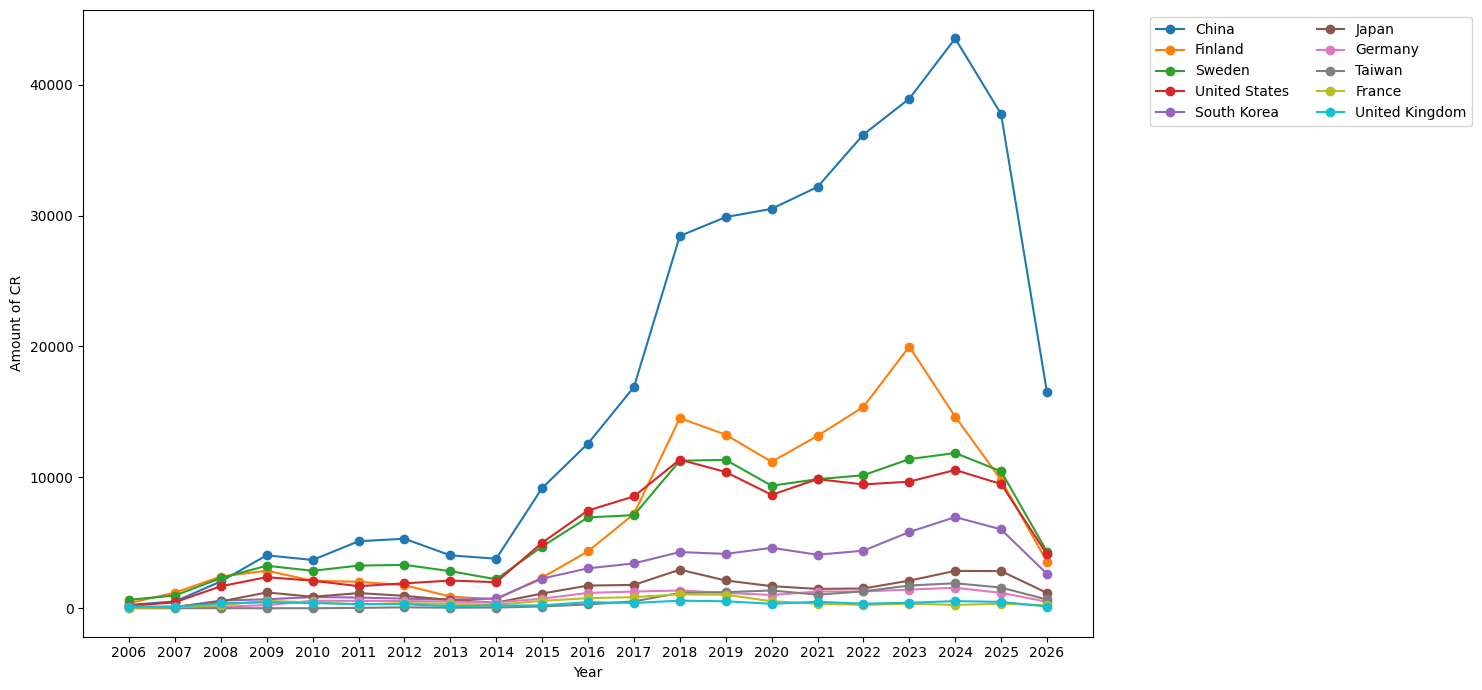

In [13]:
df = top50_total
company_country = {
    "huawei": "China",
    "ericsson": "Sweden",
    "hisilicon": "China",
    "nokia": "Finland",
    "zte": "China",
    "qualcomm": "United States",
    "samsung": "South Korea",
    "catt": "China",
    "intel": "United States",
    "ntt docomo": "Japan",
    "china mobile": "China",
    "lg": "South Korea",
    "mediatek": "Taiwan",
    "vivo": "China",
    "china telecom": "China",
    "orange": "France",
    "lenovo": "China",
    "apple": "United States",
    "rohde schwarz": "Germany",
    "oppo": "China",
    "nec": "Japan",
    "att": "United States",
    "interdigital": "United States",
    "deutsche telekom": "Germany",
    "vodafone": "United Kingdom",
    "xiaomi": "China",
    "motorola": "United States",
    "verizon": "United States",
    "keysight": "United States",
    "tmobile": "United States",
    "kddi": "Japan",
    "cisco": "United States",
    "sharp": "Japan",
    "wilus": "South Korea"
}

import pandas as pd

df_countries = pd.DataFrame(
    list(company_country.items()),
    columns=["company", "country"]
)

df = df.merge(df_countries, on="company", how="left")
df["company"] = df["country"]
df = df.drop(columns = "country")
df = df.groupby('company', as_index=False).sum()

df = top_contributers(df,2006,2026,35)


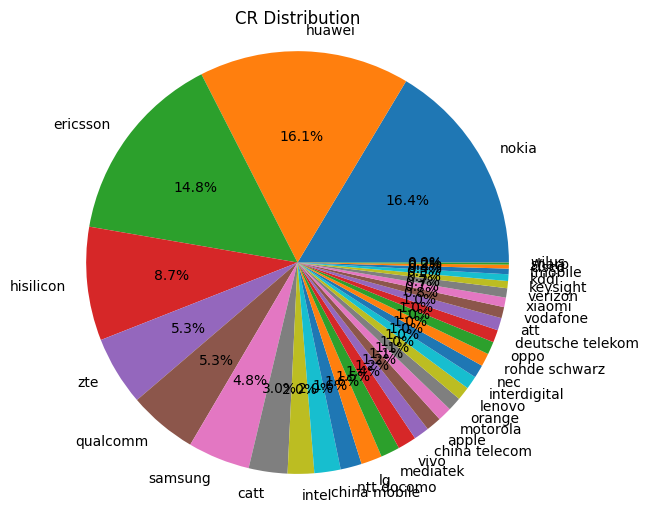

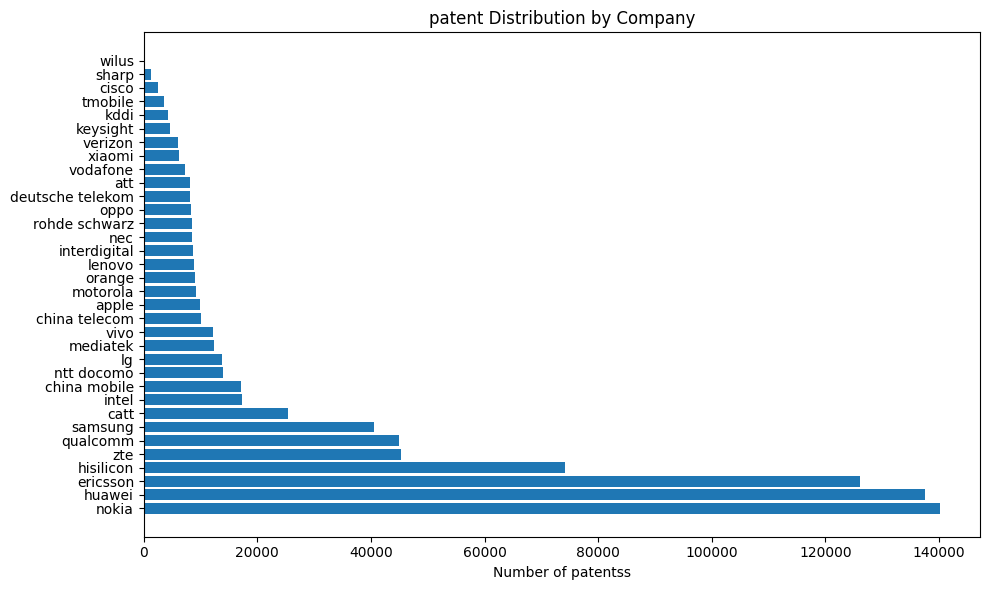

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 6))
plt.pie(
    top50_total['total'],
    labels=top50_total['company'],
    autopct='%1.1f%%'
)
plt.title('CR Distribution')
plt.axis('equal')
plt.show()


plt.figure(figsize=(10, 6))
plt.barh(top50_total['company'], top50_total['total'])

plt.title('patent Distribution by Company')
plt.xlabel('Number of patentss')

plt.tight_layout()
plt.show()

In [7]:
df = pd.read_csv('CRdata/total_DB_CR.csv')
df = df.dropna(subset = ["crspec"])

C:\Users\Bram\AppData\Local\Temp\ipykernel_24252\2446021980.py:1: DtypeWarning: Columns (0: abstract, 1: secretary_remarks, 2: ainumber, 3: ainame, 4: revisionof, 5: revisedto, 6: release, 7: crspec, 8: crspecversion, 9: workitem, 10: crnumber, 11: uicc_affected, 12: me_affected, 13: ran_affected, 14: cn_affected, 15: clauses_affected, 16: crsinpack) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('CRdata/total_DB_CR.csv')


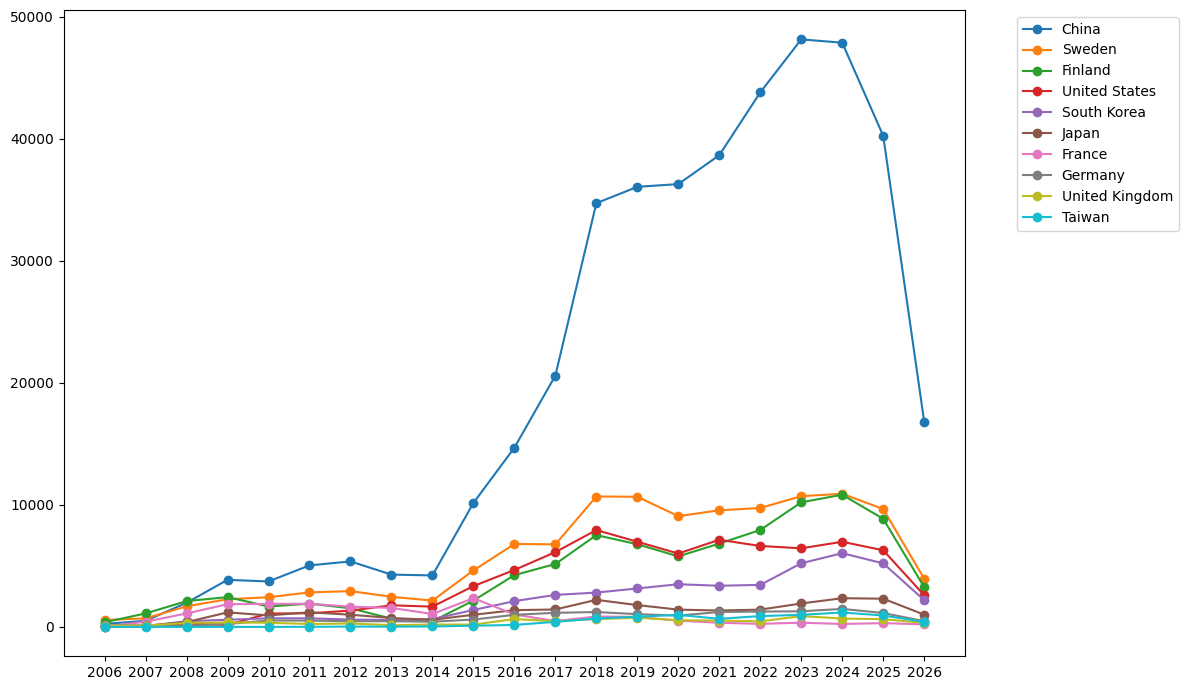

,country,2006,2007,2008,2009,2010,2011,2012,2013,2014,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,total
0,China,244.0,498.0,1973.0,3857.0,3724.0,5042.0,5368.0,4287.0,4218.0,...,34728.0,36068.0,36292.0,38660.0,43808.0,48153.0,47880.0,40249.0,16817.0,400492.0
6,Sweden,562.0,701.0,1686.0,2270.0,2430.0,2830.0,2934.0,2470.0,2154.0,...,10687.0,10667.0,9078.0,9555.0,9746.0,10713.0,10912.0,9660.0,3948.0,117243.0
1,Finland,381.0,1103.0,2114.0,2443.0,1671.0,1908.0,1528.0,676.0,458.0,...,7523.0,6774.0,5781.0,6830.0,7945.0,10211.0,10833.0,8858.0,3259.0,88592.0
10,United States,15.0,90.0,272.0,158.0,1096.0,1117.0,1335.0,1770.0,1661.0,...,7937.0,6980.0,6014.0,7142.0,6632.0,6443.0,6975.0,6282.0,2594.0,76056.0
5,South Korea,99.0,56.0,469.0,586.0,705.0,705.0,599.0,561.0,638.0,...,2813.0,3152.0,3497.0,3373.0,3443.0,5216.0,6041.0,5208.0,2195.0,43279.0
4,Japan,42.0,91.0,393.0,1190.0,941.0,1196.0,999.0,728.0,583.0,...,2218.0,1787.0,1417.0,1341.0,1416.0,1919.0,2352.0,2311.0,1003.0,24719.0
2,France,24.0,424.0,1102.0,1859.0,1886.0,1897.0,1658.0,1557.0,1058.0,...,851.0,821.0,514.0,337.0,252.0,346.0,241.0,309.0,206.0,18989.0
3,Germany,115.0,126.0,107.0,238.0,527.0,516.0,466.0,465.0,428.0,...,1218.0,1046.0,926.0,1223.0,1255.0,1279.0,1476.0,1138.0,467.0,15297.0
9,United Kingdom,100.0,106.0,327.0,371.0,340.0,239.0,278.0,137.0,196.0,...,640.0,750.0,546.0,518.0,450.0,888.0,685.0,635.0,325.0,8504.0
8,Taiwan,0.0,0.0,0.0,0.0,0.0,7.0,28.0,18.0,35.0,...,691.0,832.0,987.0,663.0,887.0,990.0,1181.0,936.0,411.0,7927.0


In [19]:
""""
Plot the amount of change requests per year for top 10 contributing countries. 
"""
import pandas as pd 
country_db= pd.read_csv("CRdata/top50_total_with_country.csv")

country_db = country_db.drop(columns = "company")
country_db = country_db.groupby("country", as_index=False).sum()

def top_contributers(df,startyear,endyear,number):
    """"
    get top contributers in change requests, 
    input: dataframe, startyear, endyear and amount of top companies you want to see
    output: plot with top contributers over the years: 2006 until 2026
    """

    df['total'] = df[[str(year) for year in range(startyear, endyear)]].sum(axis=1)
    top_total = df.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('country').T

    plt.figure(figsize=(12, 7))
    for country in df_plot.columns:
        plt.plot(df_plot.index, df_plot[country], marker='o', label=country)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return top_total
top_countries = top_contributers(country_db,2006,2026,10)


In [1]:
import pandas as pd 

## load in the data ##
patent_data1 = pd.read_csv("ISLDdata/ISLD-sample-aa.csv",sep=";")
patent_data2 = pd.read_csv("ISLDdata/ISLD-sample-ab.csv",sep=";")
patent_data3 = pd.read_csv("ISLDdata/ISLD-sample-ac.csv",sep=";")
patent_data4 = pd.read_csv("ISLDdata/ISLD-sample-ad.csv",sep=";")
patent_data5 = pd.read_csv("ISLDdata/ISLD-sample-ae.csv",sep=";")

## data alterations for the analysis ##
patent_data2.columns = patent_data1.columns
patent_data3.columns = patent_data1.columns
patent_data4.columns = patent_data1.columns
patent_data5.columns = patent_data1.columns

patent_data_total = pd.concat([patent_data1, patent_data2, patent_data3, patent_data4, patent_data5], ignore_index=True)
patent_data_total = patent_data_total.drop_duplicates()

patent_data_total = patent_data_total.dropna(subset = ["Standard"])
patent_data_total = patent_data_total[patent_data_total["Normalized_Patent"] == "Yes"]
patent_data_total = patent_data_total[patent_data_total["3GPP_Type"] == "TS"]


patent_data_total["PBPA_APP_DATE"] = pd.to_datetime(patent_data_total["PBPA_APP_DATE"]).dt.year.astype("Int64")
patent_data_total["IPRD_SIGNATURE_DATE"] = pd.to_datetime(patent_data_total["IPRD_SIGNATURE_DATE"]).dt.year.astype("Int64")
patent_data_total["COMP_LEGAL_NAME"] = patent_data_total["COMP_LEGAL_NAME"].str.strip()

#patent_data_total = patent_data_total[patent_data_total["Patent_Type"] == "Basis Patent"]



C:\Users\Bram\AppData\Local\Temp\ipykernel_124172\3886553093.py:4: DtypeWarning: Columns (0: DIPG_EXTERNAL_ID, 1: WOIT_REFERENCE, 2: WOIT_VERSION, 3: TGPP_NUMBER, 4: TGPV_VERSION, 5: Illustrative_Part, 6: Original_Application_Number, 7: Original_Publication_Number) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_data1 = pd.read_csv("ISLDdata/ISLD-sample-aa.csv",sep=";")
C:\Users\Bram\AppData\Local\Temp\ipykernel_124172\3886553093.py:5: DtypeWarning: Columns (0: Unnamed: 10, 1: Unnamed: 13, 2: Unnamed: 14, 3: Unnamed: 15, 4: Unnamed: 16, 5: 41.101, 6: Unnamed: 19, 7: Unnamed: 30, 8: Unnamed: 32, 9: Unnamed: 33) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_data2 = pd.read_csv("ISLDdata/ISLD-sample-ab.csv",sep=";")
C:\Users\Bram\AppData\Local\Temp\ipykernel_124172\3886553093.py:6: DtypeWarning: Columns (0: Unnamed: 10, 1: Unnamed: 15, 2: Unnamed: 16, 3: 04.18, 4: Unnamed: 19, 5: Unnamed: 30, 6: Unnamed: 32, 7: Unname

In [42]:
companies = [
    "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "mediatek", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att",
    "kddi", "cisco", "sharp", "wilus"
]

final_patent_data = patent_data_total[patent_data_total["COMP_LEGAL_NAME"].str.contains("huawei", case = False, na = False)]
final_patent_data["COMP_LEGAL_NAME"] = "huawei"
for company in companies:
    patent_data = patent_data_total[patent_data_total["COMP_LEGAL_NAME"].str.contains(f"{company}", case = False, na = False)]
    patent_data["COMP_LEGAL_NAME"] = f"{company}"
    final_patent_data = pd.concat([final_patent_data,patent_data], ignore_index= True)

In [44]:
company_country = {
    "huawei": "China",
    "ericsson": "Sweden",
    "hisilicon": "China",
    "nokia": "Finland",
    "zte": "China",
    "qualcomm": "United States",
    "samsung": "South Korea",
    "catt": "China",
    "intel": "United States",
    "ntt docomo": "Japan",
    "china mobile": "China",
    "lg": "South Korea",
    "mediatek": "Taiwan",
    "vivo": "China",
    "china telecom": "China",
    "orange": "France",
    "lenovo": "China",
    "apple": "United States",
    "rohde schwarz": "Germany",
    "oppo": "China",
    "nec": "Japan",
    "att": "United States",
    "interdigital": "United States",
    "deutsche telekom": "Germany",
    "vodafone": "United Kingdom",
    "xiaomi": "China",
    "motorola": "United States",
    "verizon": "United States",
    "keysight": "United States",
    "tmobile": "United States",
    "kddi": "Japan",
    "cisco": "United States",
    "sharp": "Japan",
    "wilus": "South Korea"
}

import pandas as pd

df_countries = pd.DataFrame(
    list(company_country.items()),
    columns=["COMP_LEGAL_NAME", "country"]
)
final_patent_data = final_patent_data.merge(df_countries, on="COMP_LEGAL_NAME", how="left")


In [47]:
final_patent_data.to_csv("processed_patent_db.csv")

In [66]:
import regex as re

def normalize_number(text):
    if pd.isna(text): return ""
    return re.sub(r'[^A-Za-z0-9]', '', str(text)).upper()

patent_data_total2 = patent_data_total
patent_data_total2['PATT_APPLICATION_NUMBER'] = patent_data_total2['PATT_APPLICATION_NUMBER'].apply(normalize_number)

# 3. Drop structural rows; keep one row per unique invention
patent_data_total2 = patent_data_total2.drop_duplicates(subset=['PATT_APPLICATION_NUMBER'])

In [17]:
import pandas as pd 

## load in the data ##
patent_data1 = pd.read_csv("ISLDdata/ISLD-sample-aa.csv",sep=";")
patent_data2 = pd.read_csv("ISLDdata/ISLD-sample-ab.csv",sep=";")
patent_data3 = pd.read_csv("ISLDdata/ISLD-sample-ac.csv",sep=";")
patent_data4 = pd.read_csv("ISLDdata/ISLD-sample-ad.csv",sep=";")
patent_data5 = pd.read_csv("ISLDdata/ISLD-sample-ae.csv",sep=";")

## data alterations for the analysis ##
patent_data2.columns = patent_data1.columns
patent_data3.columns = patent_data1.columns
patent_data4.columns = patent_data1.columns
patent_data5.columns = patent_data1.columns

patent_data1["PBPA_APP_DATE"] = pd.to_datetime(patent_data1["PBPA_APP_DATE"]).dt.year.astype("Int64")
patent_data2["PBPA_APP_DATE"] = pd.to_datetime(patent_data2["PBPA_APP_DATE"]).dt.year.astype("Int64")
patent_data3["PBPA_APP_DATE"] = pd.to_datetime(patent_data3["PBPA_APP_DATE"]).dt.year.astype("Int64")
patent_data4["PBPA_APP_DATE"] = pd.to_datetime(patent_data4["PBPA_APP_DATE"]).dt.year.astype("Int64")
patent_data5["PBPA_APP_DATE"] = pd.to_datetime(patent_data5["PBPA_APP_DATE"]).dt.year.astype("Int64")

patent_data1["COMP_LEGAL_NAME"] = patent_data1["COMP_LEGAL_NAME"].str.strip()
patent_data2["COMP_LEGAL_NAME"] = patent_data2["COMP_LEGAL_NAME"].str.strip()
patent_data3["COMP_LEGAL_NAME"] = patent_data3["COMP_LEGAL_NAME"].str.strip()
patent_data4["COMP_LEGAL_NAME"] = patent_data4["COMP_LEGAL_NAME"].str.strip()
patent_data5["COMP_LEGAL_NAME"] = patent_data5["COMP_LEGAL_NAME"].str.strip()

patent_data1 = patent_data1.dropna(subset = ["Standard"])
patent_data2 = patent_data2.dropna(subset = ["Standard"])
patent_data3 = patent_data3.dropna(subset = ["Standard"])
patent_data4 = patent_data4.dropna(subset = ["Standard"])
patent_data5 = patent_data5.dropna(subset = ["Standard"])

patent_data_total = pd.concat([patent_data1, patent_data2, patent_data3, patent_data4, patent_data5], ignore_index=True)
patent_data_total = patent_data_total.drop_duplicates()

C:\Users\Bram\AppData\Local\Temp\ipykernel_22264\3641657105.py:4: DtypeWarning: Columns (0: DIPG_EXTERNAL_ID, 1: WOIT_REFERENCE, 2: WOIT_VERSION, 3: TGPP_NUMBER, 4: TGPV_VERSION, 5: Illustrative_Part, 6: Original_Application_Number, 7: Original_Publication_Number) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_data1 = pd.read_csv("ISLDdata/ISLD-sample-aa.csv",sep=";")
C:\Users\Bram\AppData\Local\Temp\ipykernel_22264\3641657105.py:5: DtypeWarning: Columns (0: Unnamed: 10, 1: Unnamed: 13, 2: Unnamed: 14, 3: Unnamed: 15, 4: Unnamed: 16, 5: 41.101, 6: Unnamed: 19, 7: Unnamed: 30, 8: Unnamed: 32, 9: Unnamed: 33) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_data2 = pd.read_csv("ISLDdata/ISLD-sample-ab.csv",sep=";")
C:\Users\Bram\AppData\Local\Temp\ipykernel_22264\3641657105.py:6: DtypeWarning: Columns (0: Unnamed: 10, 1: Unnamed: 15, 2: Unnamed: 16, 3: 04.18, 4: Unnamed: 19, 5: Unnamed: 30, 6: Unnamed: 32, 7: Unnamed: 

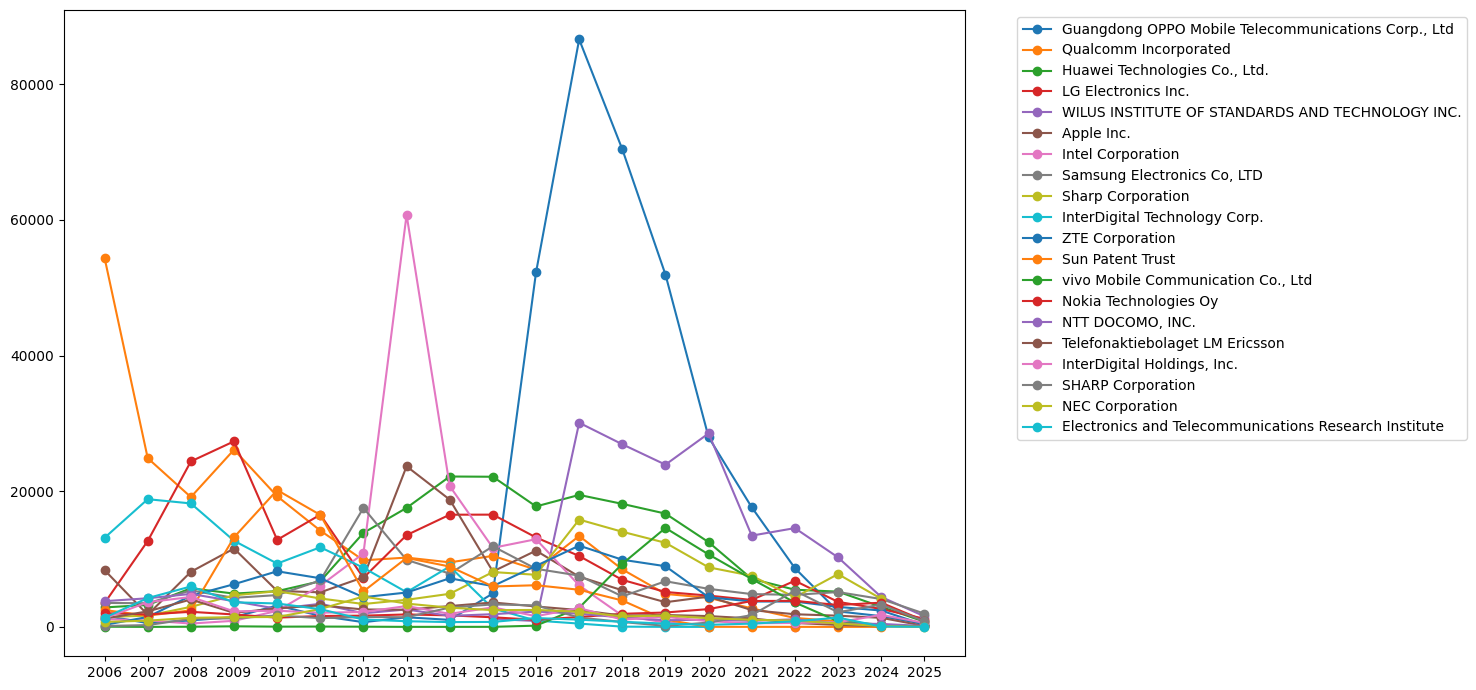

In [9]:
import pandas as pd
from functools import reduce

def countcompanies(df,startyear,endyear):
    """"
    get the amount of times each company made a change request for each year
    """
    temp = df[df["PBPA_APP_DATE"] == startyear]
    counts = temp["COMP_LEGAL_NAME"].value_counts()
    companies = pd.DataFrame({
        "company": counts.index,
        f"{startyear}": counts.values
    })

    for i in range(startyear+1, endyear+1):

        temp = df[df["PBPA_APP_DATE"] == i]
        counts = temp["COMP_LEGAL_NAME"].value_counts()
        temp_df = pd.DataFrame({
            "company": counts.index,
            str(i): counts.values
        })
        companies = pd.merge(companies,temp_df,on="company",how="outer")
    return companies
patent_total_data = countcompanies(patent_data_total,2006,2026)

def top_contributers(df,startyear,endyear,number):
    """"
    get top contributers in change requests, 
    input: dataframe, startyear, endyear and amount of top companies you want to see
    output: plot with top contributers over the years: 2006 until 2026
    """

    df['total'] = df[[str(year) for year in range(startyear, endyear)]].sum(axis=1)
    top_total = df.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T

    plt.figure(figsize=(15, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return top_total
top20_total = top_contributers(patent_total_data,2006,2026,20)

In [13]:


patent_data_oppo = patent_data_total[patent_data_total["COMP_LEGAL_NAME"].str.contains("oppo", case = False, na = False)]
counts = patent_data_oppo["PATT_APPLICATION_NUMBER"].value_counts()
counts_patent_oppo = pd.DataFrame({
    "PATT_APPLICATION_NUMBER": counts.index,
    "amount": counts.values
    })
temp = patent_data_total[patent_data_total["PATT_APPLICATION_NUMBER"] == "AU20170439046"]
print(temp["Standard"].unique())

<ArrowStringArray>
['3GPP TS 38.213', '3GPP TS 38.214', '3GPP TS 38.211', '3GPP TS 38.212']
Length: 4, dtype: str


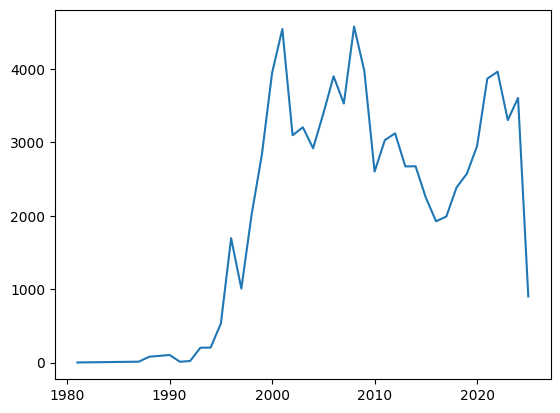

In [48]:
amount_patents_by_year = result.groupby("years", as_index=False)["amount_standards"].sum()

import matplotlib.pyplot as plt
plt.plot(amount_patents_by_year["years"],amount_patents_by_year["amount_standards"])

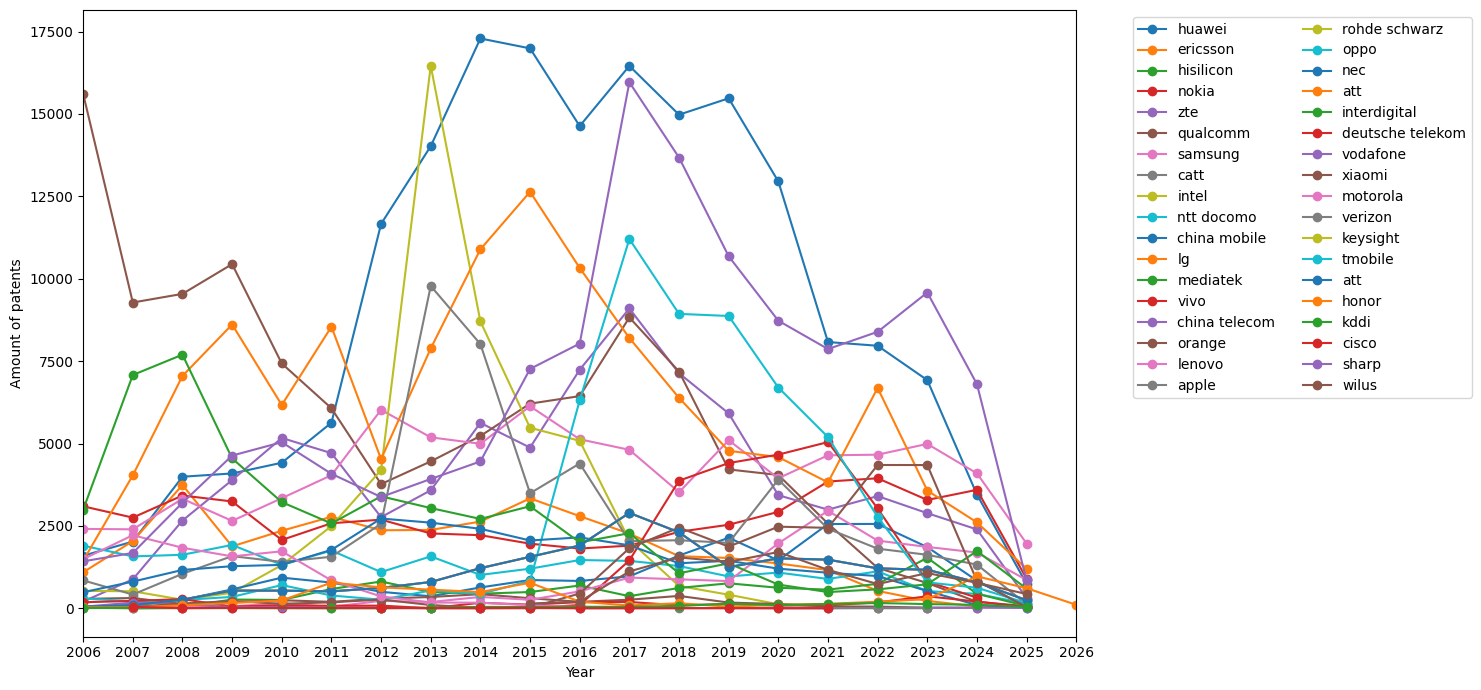

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

#patent_data_total = pd.read_csv("patent_data_total.csv")

companies = [
    "huawei", "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "mediatek", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att", "honor",
    "kddi", "cisco", "sharp", "wilus"
]

def getpatents(company):
    """"
    getpatents takes as input the string name of a company, does not have to be exact, but matches the string 
    and gives as output two variables
    results: 
        PATT_APPLICATION_NUMBER : patent application number
        count                   : amount of times this patent was mentioned in big database
        standards               : all the standards the patent was used for 
        amount_standards        : the amount of standards named in standards
    
    amount_patents_by_year:
        years                   : the year for which the patent was applied
        amount_standards        : total standards produced by a company in a year

    IMPORTANT:
        ensure that patent_data_total is loaded before this definition is used. 
    """
    patent_data = patent_data_total[patent_data_total["COMP_LEGAL_NAME"].str.contains(f"{company}", case = False, na = False)]
    patent_data["TGPP_NUMBER"] = patent_data["TGPP_NUMBER"].astype(str)
    
    result = patent_data.groupby("PATT_APPLICATION_NUMBER").agg(
        count=("PATT_APPLICATION_NUMBER", "size"),
        years=("PBPA_APP_DATE", lambda x: sorted({int(i) for i in x})),
        country_of_registration=("Country_Of_Registration", lambda x: sorted(set(x))),
        standards = ("TGPP_NUMBER", lambda x: sorted(set(x)))
            ).reset_index()
    result["years"] = result["years"].apply(lambda x: x[0] if isinstance(x, list) else x)
    result["country_of_registration"] = result["country_of_registration"].apply(lambda x: x[0])
    result["amount_standards"] = result["standards"].apply(len)
    result = result.sort_values(by="count", ascending=False)
    
    amount_patents_by_year = result.groupby("years", as_index=False)["amount_standards"].sum()
    
    return result, amount_patents_by_year   

processed_patents = pd.DataFrame(columns=['PATT_APPLICATION_NUMBER', 'count', 'years', 'country_of_registration', 'standards', 'amount_standards', 'company'])
## figure of patents per year for each company ##
plt.figure(figsize=(15, 7))
for j in companies:
    patent_data,plot_patent = getpatents(j)
    patent_data['company'] = j
    processed_patents = pd.concat([processed_patents, patent_data], ignore_index = True)
    plt.plot(plot_patent["years"],plot_patent["amount_standards"],marker='o', label = j)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol = 2)
plt.xlabel("Year")
plt.ylabel("Amount of patents")
plt.xlim(2006, 2026)
plt.xticks(range(2006, 2027))
plt.tight_layout()
plt.show()

In [29]:
processed_patents.to_csv("processed_patents.csv")

0


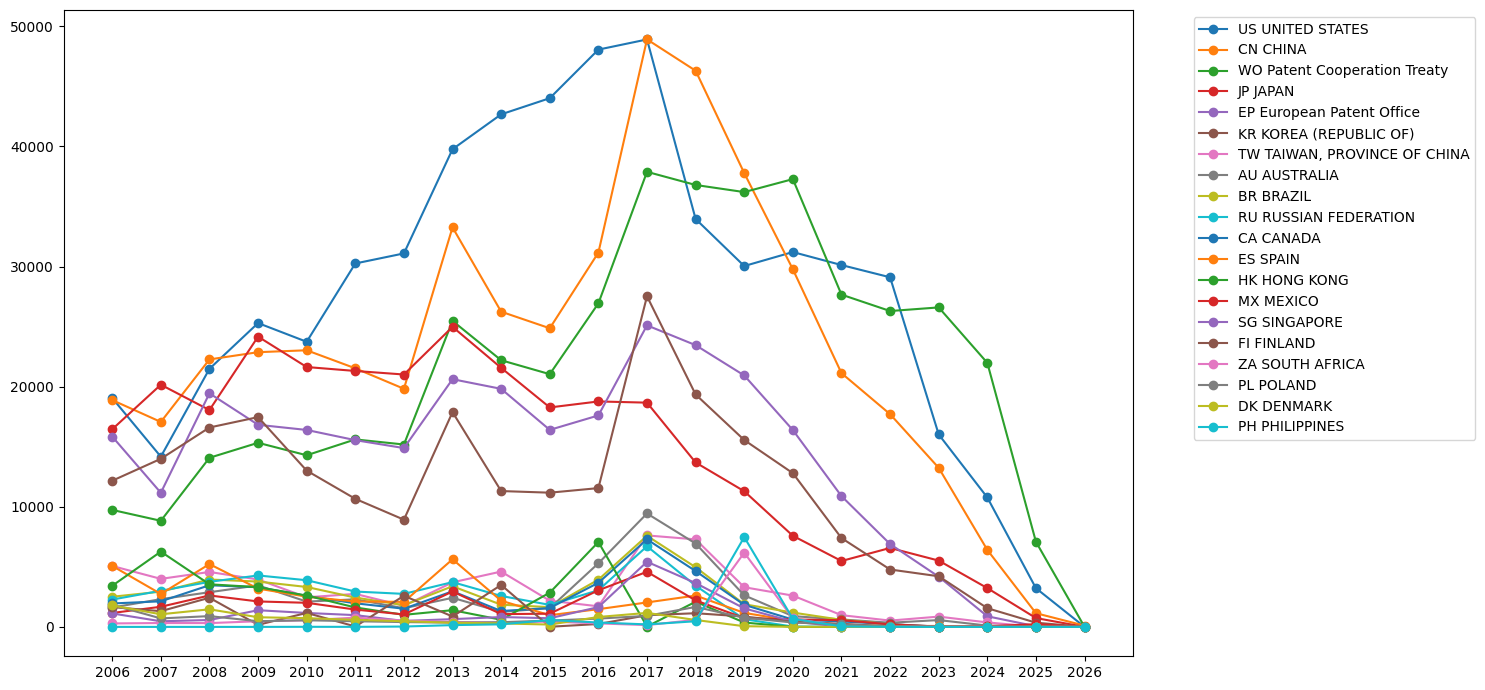

In [ ]:
import pandas as pd
from functools import reduce

def countcountries(df,startyear,endyear):
    """"
    get the amount of times each company made a change request for each year
    """
    temp = df[df["PBPA_APP_DATE"] == startyear]
    counts = temp["Country_Of_Registration"].value_counts()
    companies = pd.DataFrame({
        "company": counts.index,
        f"{startyear}": counts.values
    })

    for i in range(startyear+1, endyear+1):

        temp = df[df["PBPA_APP_DATE"] == i]
        counts = temp["Country_Of_Registration"].value_counts()
        temp_df = pd.DataFrame({
            "company": counts.index,
            str(i): counts.values
        })
        companies = pd.merge(companies,temp_df,on="company",how="outer")
    return companies
patent_company1=countcountries(patent_data1,2006,2026)
patent_company2=countcountries(patent_data2,2006,2026)
patent_company3=countcountries(patent_data3,2006,2026)
patent_company4=countcountries(patent_data4,2006,2026)
patent_company5=countcountries(patent_data5,2006,2026)

dfs = [
    patent_company1,
    patent_company2,
    patent_company3,
    patent_company4,
    patent_company5,
]
patent_total_data = (
    pd.concat(dfs, ignore_index=True)
      .groupby("company", as_index=False)
      .sum(numeric_only=True)
)

def top_contributers(df,startyear,endyear,number):
    """"
    get top contributers in change requests, 
    input: dataframe, startyear, endyear and amount of top companies you want to see
    output: plot with top contributers over the years: 2006 until 2026
    """

    df['total'] = df[[str(year) for year in range(startyear, endyear)]].sum(axis=1)
    top_total = df.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T

    plt.figure(figsize=(15, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return top_total
top20_total = top_contributers(patent_total_data,2006,2026,20)


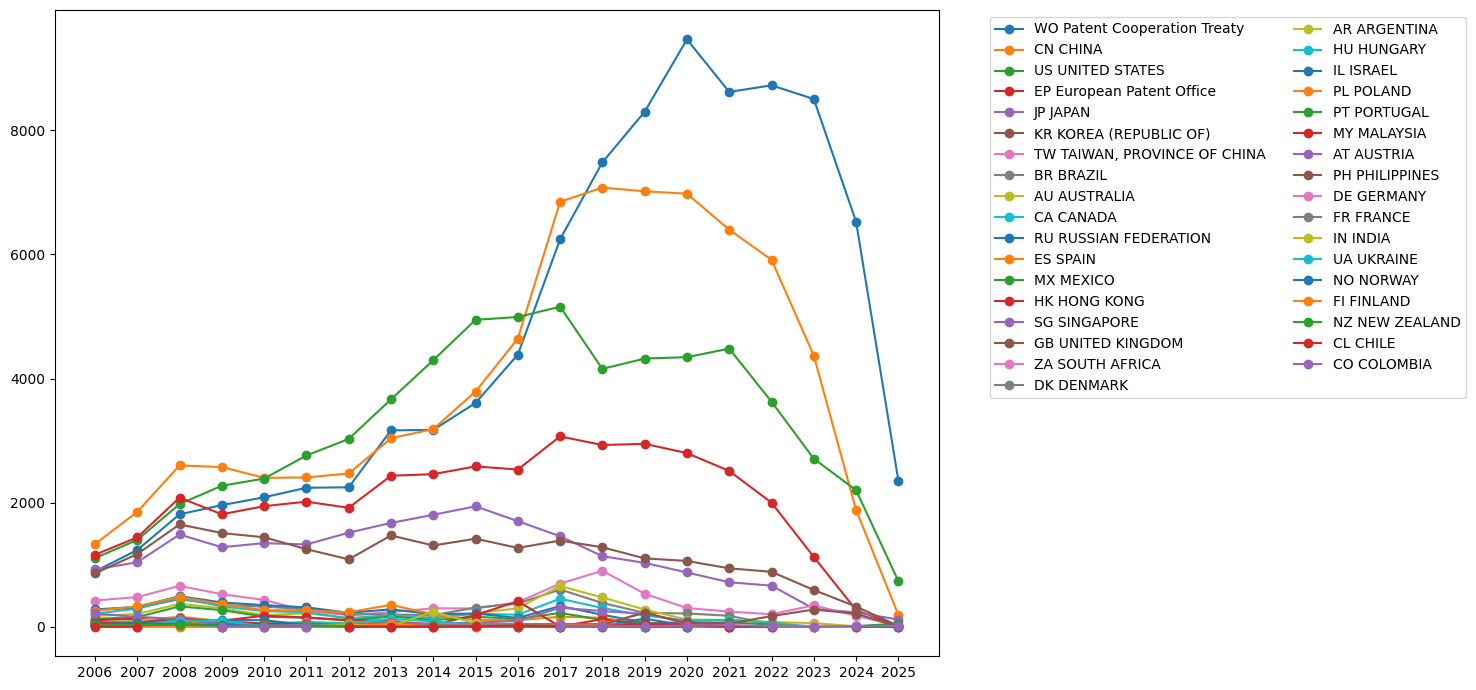

In [ ]:
import pandas as pd
from functools import reduce

df = pd.read_csv("processed_patents.csv")
df = df.iloc[:, 1:]

def countcountries(df,startyear,endyear):
    """"
    get the amount of times each company made a change request for each year
    """
    temp = df[df["years"] == startyear]
    counts = temp["country_of_registration"].value_counts()
    companies = pd.DataFrame({
        "company": counts.index,
        f"{startyear}": counts.values
    })

    for i in range(startyear+1, endyear+1):

        temp = df[df["years"] == i]
        counts = temp["country_of_registration"].value_counts()
        temp_df = pd.DataFrame({
            "company": counts.index,
            str(i): counts.values
        })
        companies = pd.merge(companies,temp_df,on="company",how="outer")
    return companies

plot_companies = countcountries(df, 2006,2026)

def top_contributers(df,startyear,endyear,number):
    """"
    get top contributers in change requests, 
    input: dataframe, startyear, endyear and amount of top companies you want to see
    output: plot with top contributers over the years: 2006 until 2026
    """

    df['total'] = df[[str(year) for year in range(startyear, endyear)]].sum(axis=1)
    top_total = df.nlargest(number,'total')

    import matplotlib.pyplot as plt
    df_plot = top_total
    df_plot = df_plot.drop(columns = 'total')
    df_plot = df_plot.set_index('company').T

    plt.figure(figsize=(15, 7))
    for company in df_plot.columns:
        plt.plot(df_plot.index, df_plot[company], marker='o', label=company)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol = 2)
    plt.xlabel("Year")
    plt.ylabel("Amount of patents")
    plt.tight_layout()
    plt.show()
    return top_total
top35_total = top_contributers(plot_companies,2006,2026,35)


In [2]:
import pandas as pd 

processed_patents = pd.read_csv("processed_patents.csv")
processed_patents = processed_patents.iloc[:, 1:]

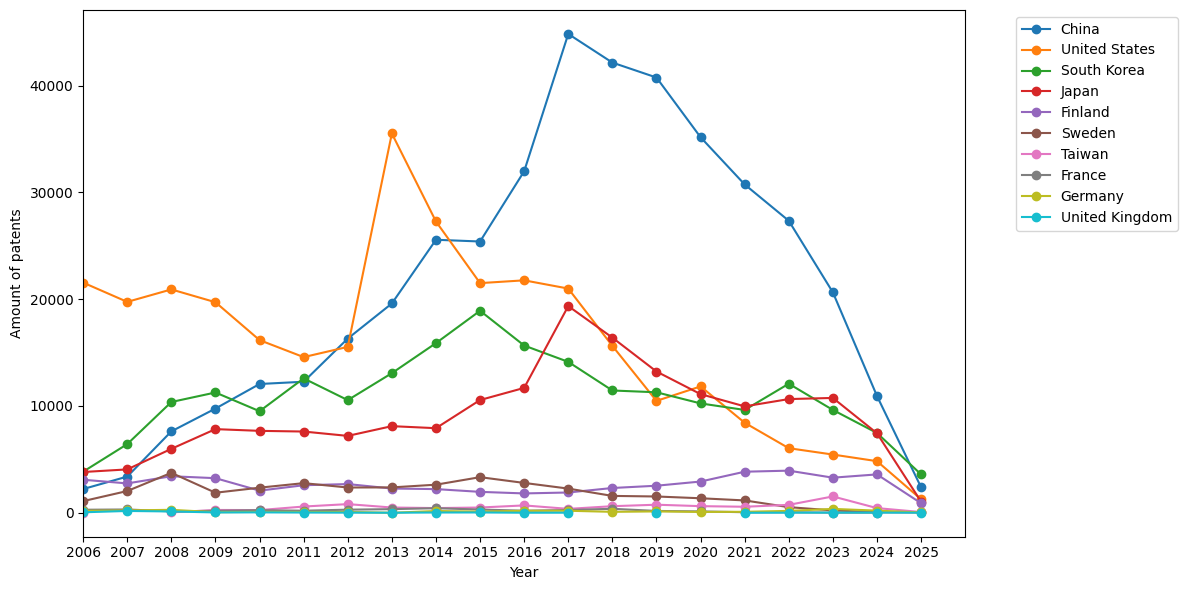

In [ ]:

import pandas as pd 
processed_patents = pd.read_csv("processed_patents.csv")
processed_patents = processed_patents.iloc[:, 1:]
df = processed_patents
company_country = {
    "huawei": "China",
    "ericsson": "Sweden",
    "hisilicon": "China",
    "nokia": "Finland",
    "zte": "China",
    "qualcomm": "United States",
    "samsung": "South Korea",
    "catt": "China",
    "intel": "United States",
    "ntt docomo": "Japan",
    "china mobile": "China",
    "lg": "South Korea",
    "mediatek": "Taiwan",
    "vivo": "China",
    "china telecom": "China",
    "orange": "France",
    "lenovo": "China",
    "apple": "United States",
    "rohde schwarz": "Germany",
    "oppo": "China",
    "nec": "Japan",
    "att": "United States",
    "interdigital": "United States",
    "deutsche telekom": "Germany",
    "vodafone": "United Kingdom",
    "xiaomi": "China",
    "motorola": "United States",
    "verizon": "United States",
    "keysight": "United States",
    "tmobile": "United States",
    "kddi": "Japan",
    "cisco": "United States",
    "sharp": "Japan",
    "wilus": "South Korea"
}

import pandas as pd

df_countries = pd.DataFrame(
    list(company_country.items()),
    columns=["company", "country"]
)

df = df.merge(df_countries, on="company", how="left")



new_df = df.pivot_table(
    index="country",
    columns="years",
    values="amount_standards",
    aggfunc="sum"
)


years = list(range(2006, 2027))
df_plot = new_df.reindex(columns=years)
df_plot['total'] = df_plot[[year for year in years]].sum(axis=1)
df_plot = df_plot.sort_values(by="total", ascending=False)
df_plot = df_plot.drop(columns = "total")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for country in df_plot.index:
    plt.plot(df_plot.columns, df_plot.loc[country], marker = 'o', label=country)

plt.xlim(2006, 2026)
plt.xlabel("Year")
plt.ylabel("Amount of patents")
plt.xticks(range(2006, 2026))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [34]:
df_plot['total'] = df_plot[[year for year in years]].sum(axis=1)
df_plot = df_plot.sort_values(by="total", ascending=False)